Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Expression_TE_DESeq.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\DEA_TE_DESeq.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Clinical_Data_Xiang20.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\TE_Intergenic_With_Distances.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,Mut_D0,Mut_D10,Mut_D18,Mut_D32,Mut_D46,Mut_D74,WT_D0,WT_D10,WT_D18,WT_D32,WT_D46,WT_D74
0,TE_L2a_dup1,2,2,0,1,0,2,1,2,3,0,0,1
1,TE_L3_dup1,0,0,0,1,1,5,0,0,0,3,0,4
2,TE_L2c_dup5,4,2,0,4,0,2,0,0,0,0,0,2
3,TE_L2a_dup12,1,3,1,8,1,2,6,0,3,5,1,1
4,TE_AluSq2_dup2,6,3,2,0,0,0,2,0,0,0,1,4


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_L1M2c_dup390,59.267818,9.362789,1.052127,8.898915,5.639530e-19,1.290240e-13
1,TE_Tigger1_dup4644,59.044212,-6.559214,0.815149,-8.046639,8.509843e-16,9.734623e-11
2,TE_HERVK3-int_dup119,46.356359,-9.080119,1.146879,-7.917243,2.428342e-15,1.851894e-10
3,TE_L1MA8_dup4319,23.365414,-8.088186,1.045784,-7.734086,1.041489e-14,5.956924e-10
4,TE_HERVL40-int_dup472,55.056513,-3.521627,0.471528,-7.468536,8.109208e-14,3.581179e-09


Volcano plot

Classification
Non-significant    228577
Down-regulated        136
Up-regulated           72
Name: count, dtype: int64
Total tes:
457445
41384
          0         1         2                  TE      4  5          6  \
0      chr1    200408    200714       TE_L1MB3_dup2   1294  +         L1   
1      chr1    895543    895868  TE_HERVK9-int_dup2   2132  -       ERVK   
2      chr1    896099    897617  TE_HERVK9-int_dup4  11200  -       ERVK   
3      chr1    897609    898198  TE_HERVK9-int_dup5   4252  -       ERVK   
4      chr1    901362    901555      TE_MER67A_dup1    407  -       ERV1   
...     ...       ...       ...                 ...    ... ..        ...   
16598  chrY  26478700  26478917     TE_L2b_dup98356    206  +         L2   
16599  chrY  26479018  26479233   TE_MLT1A1_dup6875   1015  -  ERVL-MaLR   
16600  chrY  26483879  26485392   TE_L1PA15_dup8568   5233  -         L1   
16601  chrY  26488462  26490101    TE_L1M4_dup22007   4695  +         L1   
16602  chrY  26490165

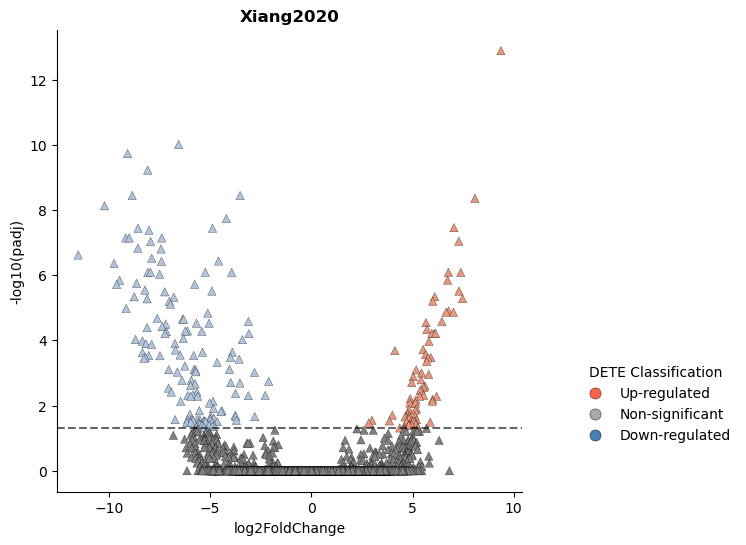

In [5]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Xiang2020', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação

    print(dea_df['Classification'].value_counts())
    

    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])
    

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False, marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [6]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df.head()

     Mut_D0   Mut_D10   Mut_D18   Mut_D32   Mut_D46   Mut_D74     WT_D0  \
0  0.535879  0.398376  0.000000  0.248916  0.000000  0.575125  0.325777   
1  0.000000  0.000000  0.000000  0.248916  0.403955  1.153491  0.000000   
2  0.925734  0.398376  0.000000  0.810035  0.000000  0.575125  0.000000   
3  0.292679  0.562704  0.362466  1.325679  0.403955  0.575125  1.333445   
4  1.232339  0.562704  0.651906  0.000000  0.000000  0.000000  0.591372   

    WT_D10     WT_D18    WT_D32    WT_D46    WT_D74  
0  0.714739  0.874258  0.000000  0.000000  0.244761  
1  0.000000  0.000000  0.770354  0.000000  0.798743  
2  0.000000  0.000000  0.000000  0.000000  0.453957  
3  0.000000  0.874258  1.121776  0.307735  0.244761  
4  0.000000  0.000000  0.000000  0.307735  0.798743  


,Sample_Name,PC1,PC2,Condition,Run
0,Mut_D0,-195.362809,-464.182853,MECP2_mutant,SRR7551512
1,Mut_D10,-444.067788,332.549962,MECP2_mutant,SRR7551514
2,Mut_D18,-281.157734,249.726477,MECP2_mutant,SRR7551516
3,Mut_D32,240.075328,38.544513,MECP2_mutant,SRR7551518
4,Mut_D46,396.925319,-152.972265,MECP2_mutant,SRR7551520


PCA - Graph

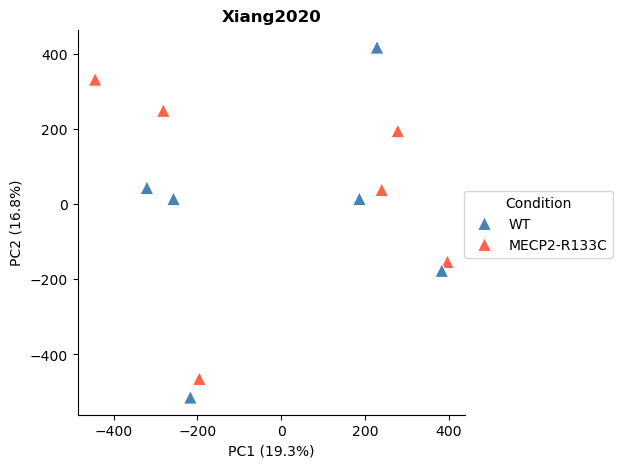

In [7]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'MECP2-R133C' : 'tomato'}

pca_df['Condition'] = pca_df['Condition'].replace({"MECP2_mutant" : "MECP2-R133C"})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, hue_order = ["WT", "MECP2-R133C"], marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Xiang2020", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [8]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'MECP2_mutant' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Xiang', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`